# Occupancy Analysis

This notebook analyzes and compares occupancy data from observations and simulated actions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

## Load Data

Load both observation and simulated action data:

In [3]:
# Load the data
obs_df = pd.read_csv('data/episode-100/monitor/observations.csv')
sim_df = pd.read_csv('data/episode-100/monitor/simulated_actions.csv')

# Display basic information about the data
print("Observations Data:")
print(obs_df.info())
print("\nSimulated Actions Data:")
print(sim_df.info())

Observations Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61055 entries, 0 to 61054
Data columns (total 50 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   month                                     61055 non-null  float64
 1   day_of_month                              61055 non-null  float64
 2   hour                                      61055 non-null  float64
 3   minutes                                   61055 non-null  float64
 4   people_occupancy_living                   61055 non-null  float64
 5   people_occupancy_kitchen                  61055 non-null  float64
 6   people_occupancy_bed1                     61055 non-null  float64
 7   people_occupancy_bed2                     61055 non-null  float64
 8   people_occupancy_bed3                     61055 non-null  float64
 9   outdoor_temperature                       61055 non-null  float64
 10  outdoor_humidit

## Filter Data

Filter both observation and simulated action data:

In [4]:
STEPS = 1000
obs_df = obs_df[:STEPS]
sim_df = sim_df[:STEPS]

## Data Preprocessing

Identify and prepare occupancy-related columns:

In [5]:
# Identify occupancy columns (you may need to adjust these based on your actual column names)
occupancy_cols_obs = [col for col in obs_df.columns if 'occupancy' in col.lower()]
occupancy_cols_sim = [col for col in sim_df.columns]

print("Occupancy columns in observations:", occupancy_cols_obs)
print("Occupancy columns in simulated actions:", occupancy_cols_sim)

Occupancy columns in observations: ['people_occupancy_living', 'people_occupancy_kitchen', 'people_occupancy_bed1', 'people_occupancy_bed2', 'people_occupancy_bed3']
Occupancy columns in simulated actions: ['flow_livroom', 'flow_kitchen', 'flow_bed1', 'flow_bed2', 'flow_bed3', 'water_temperature']


## Time Series Comparison

Create line plots to compare occupancy over time:

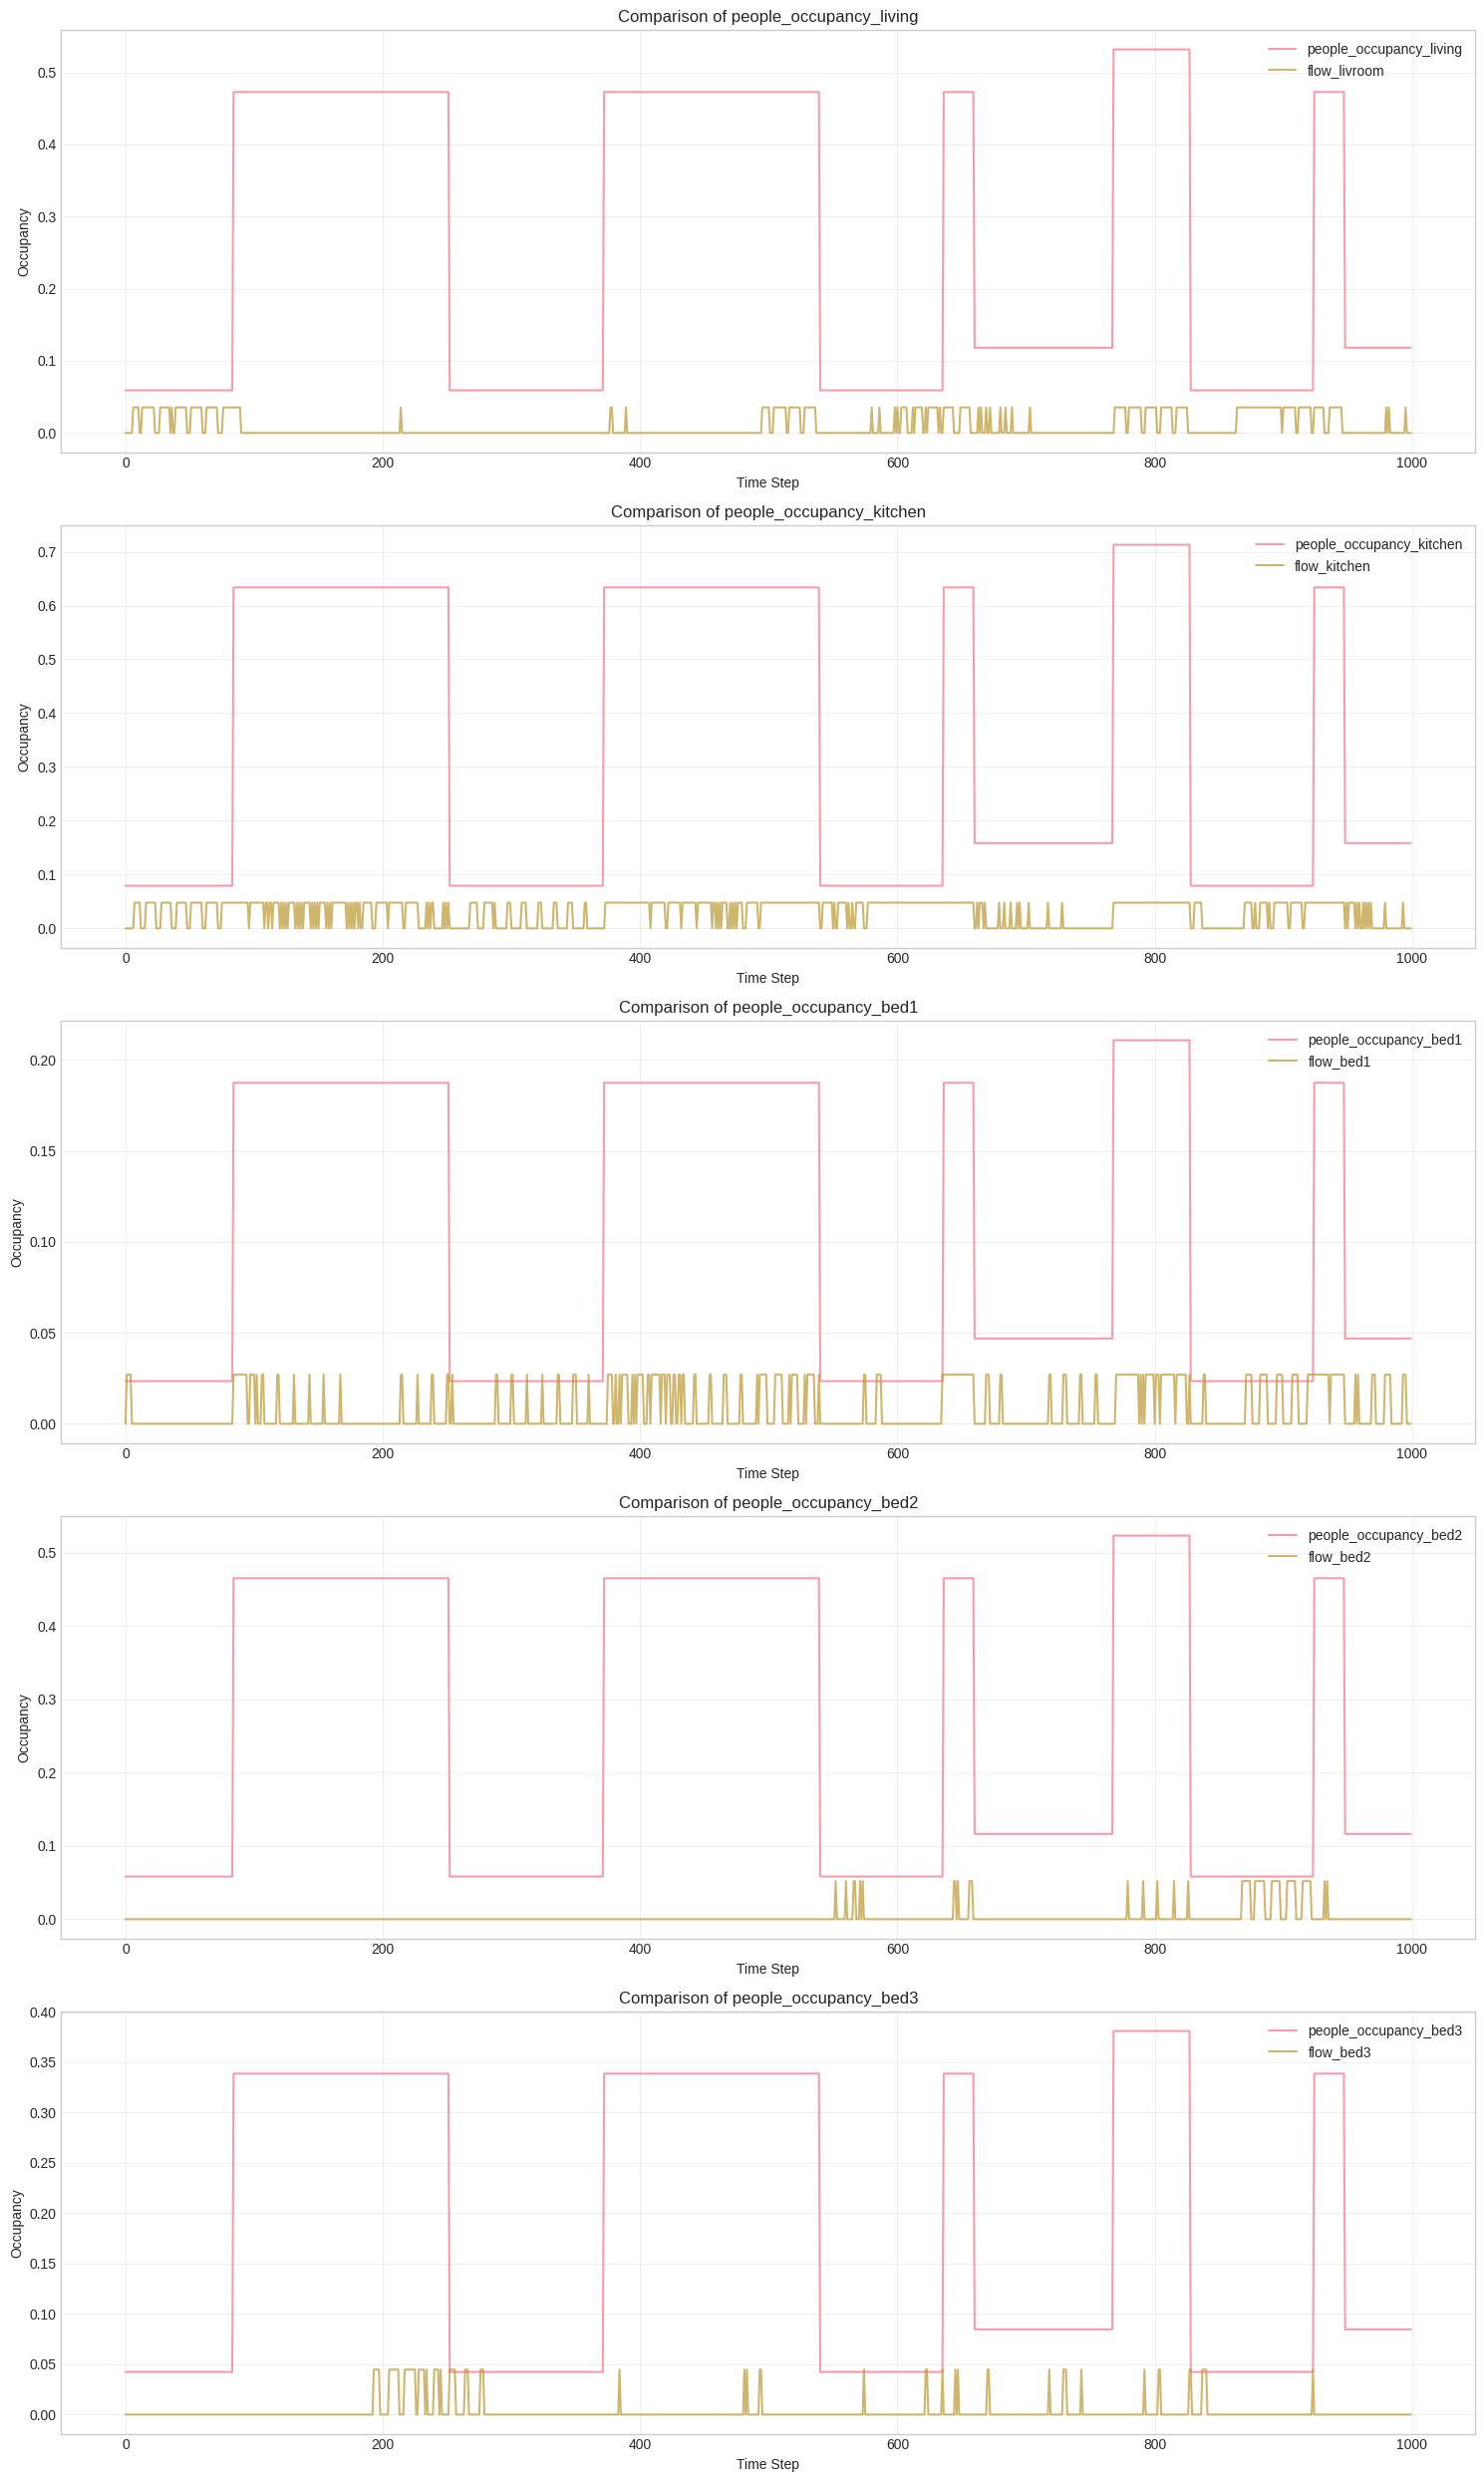

In [6]:
# Create time series plots
fig, axes = plt.subplots(len(occupancy_cols_obs), 1, figsize=(15, 5*len(occupancy_cols_obs)))

for i, col in enumerate(occupancy_cols_obs):
    if len(occupancy_cols_obs) == 1:
        ax = axes
    else:
        ax = axes[i]
        
    # Plot observation data
    #print(obs_df[col])
    ax.plot(obs_df[col], label=col, alpha=0.7)
    
    # Plot corresponding simulated data if available
    ax.plot(sim_df.iloc[:, i], label=sim_df.columns[i], alpha=0.7)
    
    ax.set_title(f'Comparison of {col}')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Occupancy')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Statistical Analysis

Compare statistical properties of occupancy data:

In [22]:
# Calculate and compare statistics
stats_comparison = pd.DataFrame()

for i, col in enumerate(occupancy_cols_obs):
    stats_comparison[f'{col}_obs_mean'] = [obs_df[col].mean()]
    stats_comparison[f'{col}_sim_mean'] = [sim_df.iloc[:, i].mean()]
    stats_comparison[f'{col}_obs_std'] = [obs_df[col].std()]
    stats_comparison[f'{col}_sim_std'] = [sim_df.iloc[:, i].std()]
    stats_comparison[f'{col}_correlation'] = [obs_df[col].corr(sim_df.iloc[:, i])]

stats_comparison.T

,0
people_occupancy_living_obs_mean,0.255695
people_occupancy_living_sim_mean,0.009699
people_occupancy_living_obs_std,0.202533
people_occupancy_living_sim_std,0.015795
people_occupancy_living_correlation,-0.007114
people_occupancy_kitchen_obs_mean,0.342848
people_occupancy_kitchen_sim_mean,0.027867
people_occupancy_kitchen_obs_std,0.271565
people_occupancy_kitchen_sim_std,0.023580
people_occupancy_kitchen_correlation,0.301742


## Distribution Comparison

Compare the distributions of occupancy values:

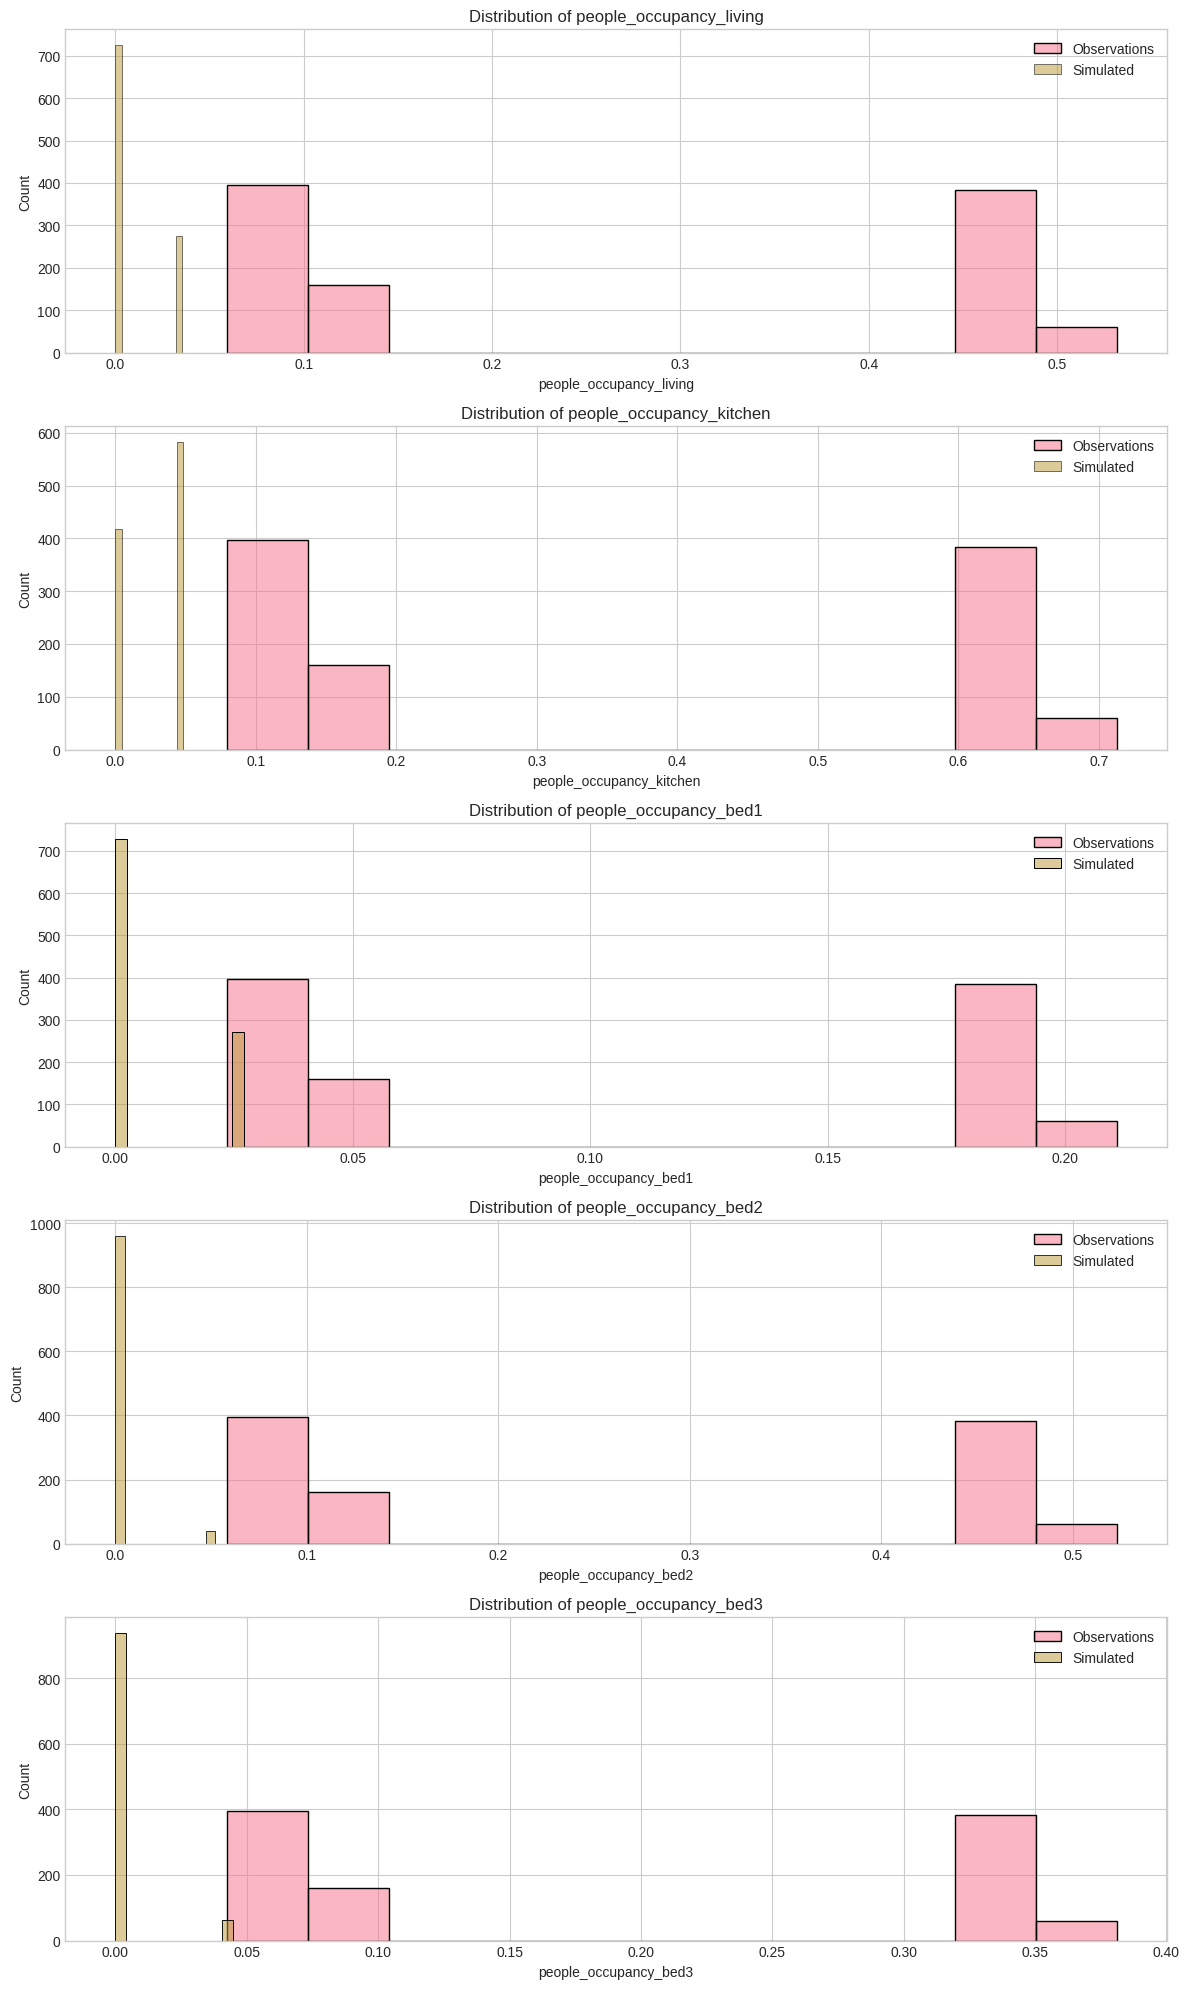

In [23]:
# Create distribution plots
fig, axes = plt.subplots(len(occupancy_cols_obs), 1, figsize=(12, 4*len(occupancy_cols_obs)))

for i, col in enumerate(occupancy_cols_obs):
    if len(occupancy_cols_obs) == 1:
        ax = axes
    else:
        ax = axes[i]
        
    
    sns.histplot(data=obs_df[col], ax=ax, label='Observations', alpha=0.5)
    sns.histplot(data=sim_df.iloc[:, i], ax=ax, label='Simulated', alpha=0.5)
    ax.set_title(f'Distribution of {col}')
    ax.legend()

plt.tight_layout()
plt.show()

## Correlation Analysis

Analyze correlations between different occupancy measures:

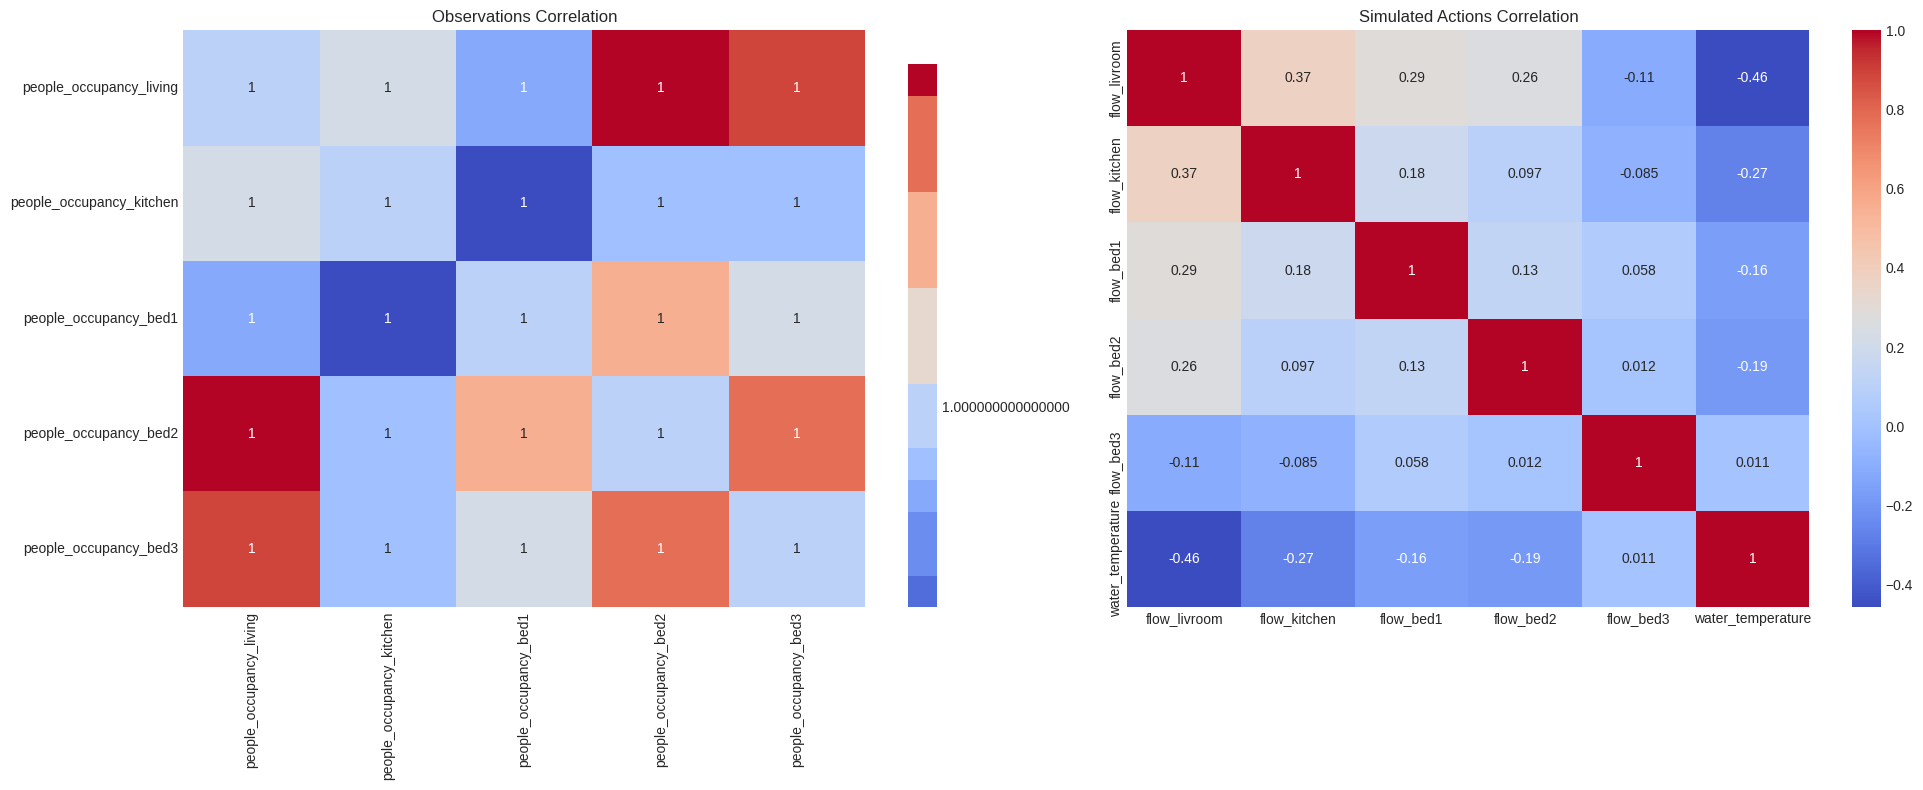

In [24]:
# Create correlation heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Observations correlation
obs_corr = obs_df[occupancy_cols_obs].corr()
sns.heatmap(obs_corr, annot=True, cmap='coolwarm', ax=ax1)
ax1.set_title('Observations Correlation')

# Simulated actions correlation
sim_corr = sim_df.corr()
sns.heatmap(sim_corr, annot=True, cmap='coolwarm', ax=ax2)
ax2.set_title('Simulated Actions Correlation')

plt.tight_layout()
plt.show()